# Тестовое задание №1

Сгенерировать синтетический датасет для задачи классификации, построить модели с использованием различных алгоритмов, провести поиск наилучших гиперпараметров и оценить качество моделей с использованием коэффициента Джини.

In [ ]:
# Подключаем необходимые библиотеки
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [ ]:
# Генерация данных
X, y = make_blobs(n_samples=1000, n_features=2, centers=2, cluster_std=3.8, center_box=(-6.0,6.0), random_state=42)

In [ ]:
# Разделение данных на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

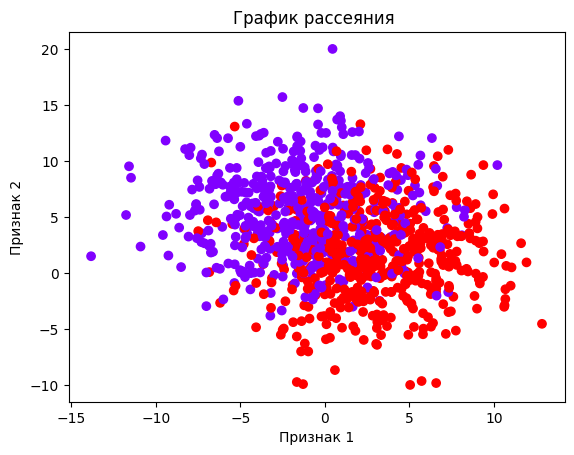

In [ ]:
# Визуализация датасета
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'rainbow')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('График рассеяния ')
plt.show()

In [ ]:
# Стандартизация признаков
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Создание моделей
LogRegression = LogisticRegression()
SupportVector = SVC(probability = True)
DecisionTree = DecisionTreeClassifier()
RandomForest = RandomForestClassifier()

In [ ]:
# GridSearch для логистической регрессии
params = {'C': [0.1, 1, 10]}
clf = GridSearchCV(LogRegression, params, scoring='roc_auc')
clf.fit(X_train_scaled, y_train)

best_estimator = clf.best_estimator_
y_pred = best_estimator.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)
gini_score = 2 * roc_auc - 1

print('Лучшие параметры модели логистической регрессии:', clf.best_params_)
print(f'Значение коэффициента Джини для модели логистической регрессии: {gini_score:.4f}')

Лучшие параметры модели логистической регрессии: {'C': 0.1}
Значение коэффициента Джини для модели логистической регрессии: 0.8131


In [ ]:
# GridSearch для опорных векторов
params = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
clf = GridSearchCV(SupportVector, params, scoring='roc_auc')
clf.fit(X_train_scaled, y_train)

best_estimator = clf.best_estimator_
y_pred = best_estimator.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)
gini_score = 2 * roc_auc - 1

print('Лучшие параметры модели опорных векторов:', clf.best_params_)
print(f'Значение коэффициента Джини для модели опорных векторов: {gini_score:.4f}')

Лучшие параметры модели опорных векторов: {'C': 10, 'gamma': 0.01}
Значение коэффициента Джини для модели опорных векторов: 0.8176


In [ ]:
# GridSearch для дерева решений
params = {'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10]}
clf = GridSearchCV(DecisionTree, params, scoring='roc_auc')
clf.fit(X_train_scaled, y_train)

best_estimator = clf.best_estimator_
y_pred = best_estimator.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)
gini_score = 2 * roc_auc - 1

print('Лучшие параметры модели дерева решений:', clf.best_params_)
print(f'Значение коэффициента Джини для модели дерева решений: {gini_score:.4f}')

Лучшие параметры модели дерева решений: {'max_depth': 5, 'min_samples_split': 10}
Значение коэффициента Джини для модели дерева решений: 0.6884


In [ ]:
# GridSearch для случайного леса
params = {'max_depth': [5, 10, 20], 'n_estimators': [10, 50, 100]}
clf = GridSearchCV(RandomForest, params, scoring='roc_auc')
clf.fit(X_train_scaled, y_train)

best_estimator = clf.best_estimator_
y_pred = best_estimator.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)
gini_score = 2 * roc_auc - 1

print('Лучшие параметры модели случайного леса:', clf.best_params_)
print(f'Значение коэффициента Джини для модели случайного леса: {gini_score:.4f}')

Лучшие параметры модели случайного леса: {'max_depth': 5, 'n_estimators': 100}
Значение коэффициента Джини для модели случайного леса: 0.7854
